In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('master_table_v2_uk_inflation_war_baseline_with_ppi.csv')
df['date'] = pd.to_datetime(df['date'])

energy_col = None
for col in df.columns:
    if 'housing' in col.lower() or 'energy' in col.lower() or 'elec' in col.lower():
        energy_col = col
        break
if energy_col is None:
    energy_col = 'cpih_yoy'

# Filter data
df_recent = df[df['date'] >= '2018-01-01'].copy()
war_start = pd.to_datetime('2022-02-01')

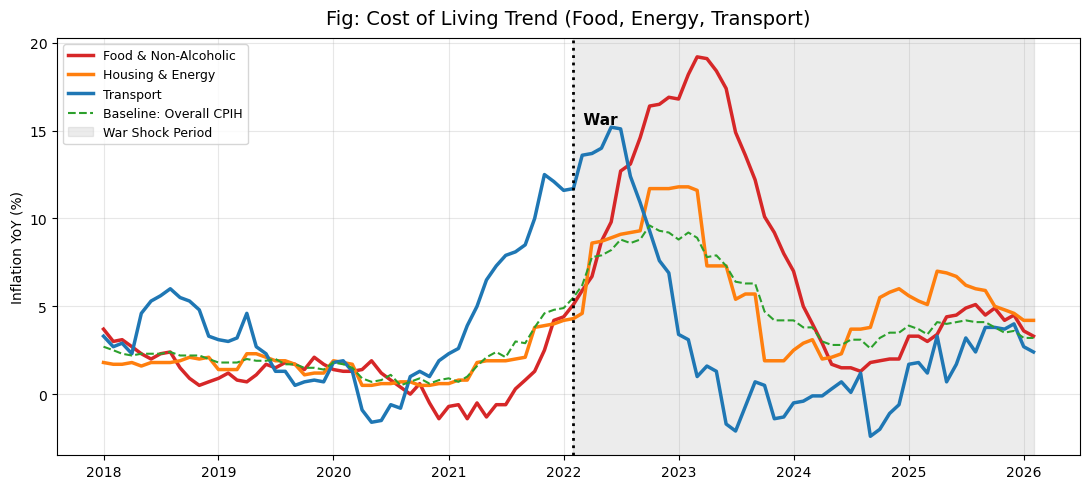

In [31]:
plt.figure(figsize=(11, 5))

# Plot lines
plt.plot(df_recent['date'], df_recent['food_yoy'], color='#D62728', linewidth=2.5, label='Food & Non-Alcoholic')
plt.plot(df_recent['date'], df_recent[energy_col], color='#FF7F0E', linewidth=2.5, label='Housing & Energy')
plt.plot(df_recent['date'], df_recent['transport_yoy'], color='#1F77B4', linewidth=2.5, label='Transport')
plt.plot(df_recent['date'], df_recent['cpih_yoy'], color='#2CA02C', linewidth=1.5, linestyle='--', label='Baseline: Overall CPIH')

# War Shadow
plt.axvspan(war_start, df_recent['date'].max(), color='grey', alpha=0.15, label='War Shock Period')
plt.axvline(war_start, color='black', linestyle=':', linewidth=2)
plt.text(pd.to_datetime('2022-02-15'), df_recent['food_yoy'].max()*0.8, ' War', color='black', fontsize=11, fontweight='bold')

plt.title('Fig: Cost of Living Trend (Food, Energy, Transport)', fontsize=14, pad=10)
plt.ylabel('Inflation YoY (%)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Fig_1_Trend_Line.png', dpi=200)
plt.show()

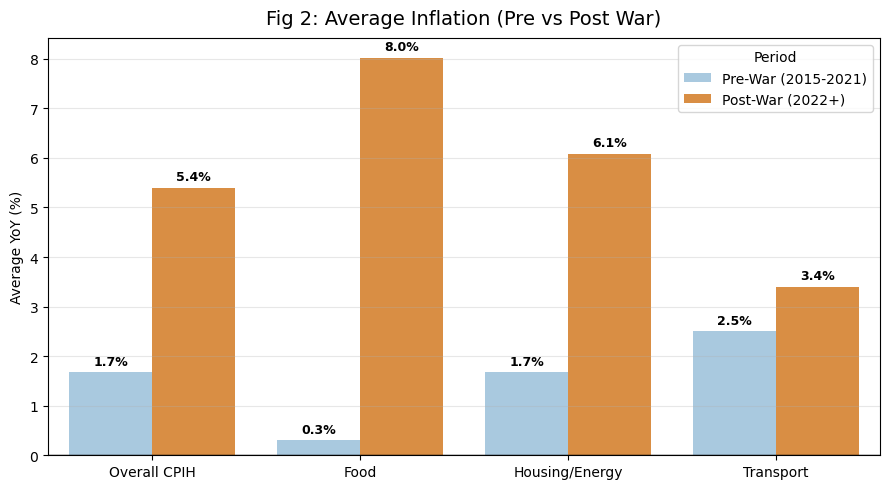

In [29]:
pre_war = df[(df['date'] >= '2015-01-01') & (df['date'] < war_start)]
post_war = df[df['date'] >= war_start]

summary_data = [
    {'Sector': 'Overall CPIH', 'Period': 'Pre-War (2015-2021)', 'Mean': pre_war['cpih_yoy'].mean()},
    {'Sector': 'Overall CPIH', 'Period': 'Post-War (2022+)', 'Mean': post_war['cpih_yoy'].mean()},
    {'Sector': 'Food', 'Period': 'Pre-War (2015-2021)', 'Mean': pre_war['food_yoy'].mean()},
    {'Sector': 'Food', 'Period': 'Post-War (2022+)', 'Mean': post_war['food_yoy'].mean()},
    {'Sector': 'Housing/Energy', 'Period': 'Pre-War (2015-2021)', 'Mean': pre_war[energy_col].mean()},
    {'Sector': 'Housing/Energy', 'Period': 'Post-War (2022+)', 'Mean': post_war[energy_col].mean()},
    {'Sector': 'Transport', 'Period': 'Pre-War (2015-2021)', 'Mean': pre_war['transport_yoy'].mean()},
    {'Sector': 'Transport', 'Period': 'Post-War (2022+)', 'Mean': post_war['transport_yoy'].mean()}
]
df_summary = pd.DataFrame(summary_data)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_summary, x='Sector', y='Mean', hue='Period', palette=['#A0CBE8', '#F28E2B'])
plt.title('Fig 2: Average Inflation (Pre vs Post War)', fontsize=14, pad=10)
plt.ylabel('Average YoY (%)')
plt.xlabel('')
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)

for p in plt.gca().patches:
    height = p.get_height()
    if height != 0:
        plt.gca().annotate(f"{height:.1f}%", (p.get_x() + p.get_width() / 2., height), 
                           ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Fig_2_Average_Bar.png', dpi=200)
plt.show()

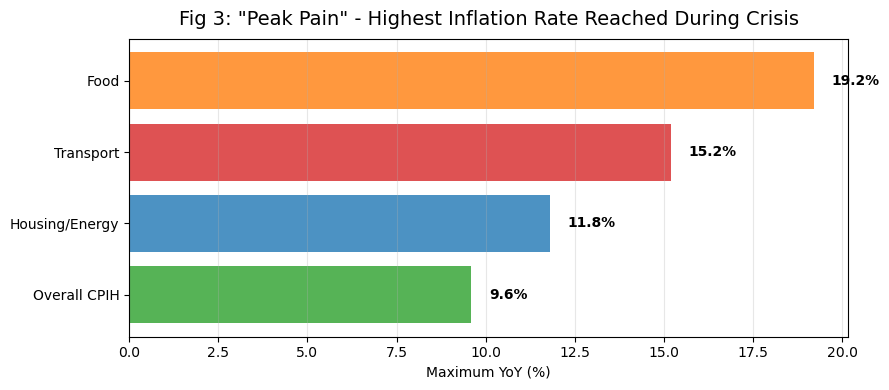

In [30]:
max_vals = {
    'Overall CPIH': post_war['cpih_yoy'].max(),
    'Transport': post_war['transport_yoy'].max(),
    'Food': post_war['food_yoy'].max(),
    'Housing/Energy': post_war[energy_col].max()
}
df_max = pd.DataFrame(list(max_vals.items()), columns=['Sector', 'Max Peak (%)']).sort_values('Max Peak (%)', ascending=True)

plt.figure(figsize=(9, 4))

colors = ['#2CA02C', '#1F77B4', '#D62728', '#FF7F0E'] 

bars = plt.barh(df_max['Sector'], df_max['Max Peak (%)'], color=colors, alpha=0.8)
plt.title('Fig 3: "Peak Pain" - Highest Inflation Rate Reached During Crisis', fontsize=14, pad=10)
plt.xlabel('Maximum YoY (%)')
plt.grid(axis='x', alpha=0.3)

# values on the bars
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.1f}%", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('Fig_3_Peak_Bar.png', dpi=200)
plt.show()
